# Imporacion de librerias a utilizar

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.optimizers import Adam
import torch
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from tensorflow.keras.applications import ResNet50, resnet50
from tensorflow.keras.preprocessing import image
import cv2
import numpy as np

# DataSets

## Dataset de autos dañados

In [ ]:
Autos_Daños = '/content/drive/MyDrive/Autos_Daños_Final'

lista_archivos_daños = os.listdir(Autos_Daños)
total_imagenes_daños = len(lista_archivos_daños)
print ("El total de imagenes con autos con daños son de:",total_imagenes_daños)

El total de imagenes con autos con daños son de: 1102


## Dataset de autos sanos

In [ ]:
Autos_Sin_Daños = '/content/drive/MyDrive/Autos_Sin_Daños_Entrenamiento_final'

lista_archivos_sin_daños = os.listdir(Autos_Sin_Daños)
total_imagenes_sin_daños = len(lista_archivos_sin_daños)
print ("El total de imagenes con autos con daños son de:",total_imagenes_sin_daños)

El total de imagenes con autos con daños son de: 371


## Grafico de las clases

In [ ]:
categorias = ['Autos con daños', 'Autos sin daños']
valores = [total_imagenes_daños, total_imagenes_sin_daños]
colores = ['red', 'blue']
fig = go.Figure(data=[go.Bar(x=categorias, y=valores, marker_color=colores)])
fig.update_layout(title_text='Comparación de imágenes de los autos con daños y sin daños')
fig.show()

En el grafico sirve para visualizar si los dataset estan balanceados o desbalanceados, en este caso, se observo que los dataset estan desbalanceados por se tienen 1102 imagens para autos con daños y solo 371 imagenes para autos sanos

# Data augmentation

## Transformaciones

En el siguente codigo se aplican transformaciones (rotacion, escalado, traslacion, volteos, etc) a todas las imagenes de autos sanos, para asi poder balancear los datasets

In [ ]:
train_dir = '/content/drive/MyDrive/Autos_Sin_Daños_Entrenamiento_final'

# Ruta del directorio donde se guardarán las imágenes aumentadas
output_dir = '/content/drive/MyDrive/Autos_Sin_Daños_Entrenamiento_final_data_3'

# Crea el directorio de salida si no existe
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Lee las imágenes del directorio
for filename in os.listdir(train_dir):
    img_path = os.path.join(train_dir, filename)
    img = cv2.imread(img_path)

    # Aplica transformaciones aleatorias a la imagen
    for i in range(3):
        # Rotación aleatoria
        angle = np.random.uniform(-30, 30)
        M = cv2.getRotationMatrix2D((img.shape[1] // 2, img.shape[0] // 2), angle, 1.0)
        rotated_img = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

        # Traslación aleatoria
        x_shift = np.random.uniform(-0.2, 0.2) * img.shape[1]
        y_shift = np.random.uniform(-0.2, 0.2) * img.shape[0]
        M = np.float32([[1, 0, x_shift], [0, 1, y_shift]])
        shifted_img = cv2.warpAffine(rotated_img, M, (img.shape[1], img.shape[0]))

        # Escalado aleatorio
        scale = np.random.uniform(0.8, 1.2)
        resized_img = cv2.resize(shifted_img, (int(img.shape[1] * scale), int(img.shape[0] * scale)))

        # Volteo horizontal aleatorio
        if np.random.rand() < 0.5:
            flipped_img = cv2.flip(resized_img, 1)
        else:
            flipped_img = resized_img

        # Guarda la imagen aumentada
        output_path = os.path.join(output_dir, f'{i}_{filename}')
        cv2.imwrite(output_path, flipped_img)

## Dataset de autos sanos luego de haber aplicado el data augmentation

In [ ]:
Autos_Sin_Daños_nuevo_OpenCV =  '/content/drive/MyDrive/Autos_Sin_Daños_Entrenamiento_final_data_3'

lista_archivos_sin_daños_nuevos_OpenCV = os.listdir(Autos_Sin_Daños_nuevo_OpenCV)
total_imagenes_sin_daños_nuevos_OpenCV = len(lista_archivos_sin_daños_nuevos_OpenCV)
print ("El total de imagenes con autos con daños son de:",total_imagenes_sin_daños_nuevos_OpenCV)

El total de imagenes con autos con daños son de: 1113


### Resultado de la imagen luego de haber aplicado data augmentation

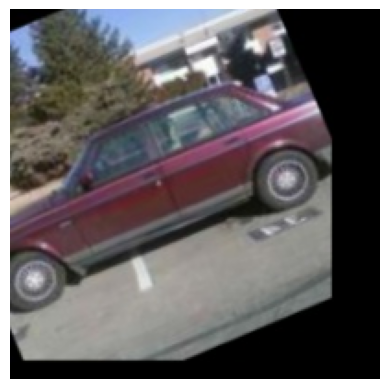

In [ ]:
img_path = '/content/drive/MyDrive/Computer Vision/1/Autos_Sanos_aumentado_OpenCV/0_1027.jpeg'

img = Image.open(img_path)
img.show()
plt.imshow(img)
plt.axis('off')
plt.show()

# Relleno de Fondos Negros

In [ ]:
img_path = '/content/drive/MyDrive/Computer Vision/1/Autos_Sanos_aumentado_OpenCV/0_1027.jpeg'

img_bgr = cv2.imread(img_path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Detectar fondo negro (valores cercanos a [0,0,0])
mask = cv2.inRange(img_bgr, (0, 0, 0), (30, 30, 30))

# Rellenar con inpaint
filled = cv2.inpaint(img_bgr, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

cv2.imwrite('imagen_rellenada.jpg', filled)

True

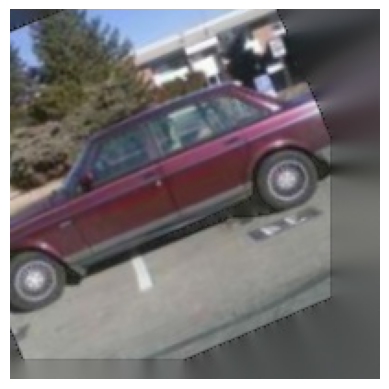

In [ ]:
img_path = 'imagen_rellenada.jpg'

img_bgr = cv2.imread(img_path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

## Resultado de imagenes luego de haber rellenado el fondo negro

In [ ]:
input_dir = '/content/drive/MyDrive/Autos_Sin_Daños_Entrenamiento_final_data_3'
output_dir = '/content/drive/MyDrive/Autos_Sin_Daños_Entrenamiento_final__relleno_v1_data_3'

os.makedirs(output_dir, exist_ok=True)

# Obtener lista de archivos de imagen
archivos = os.listdir(input_dir)
imagenes = [f for f in archivos if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

# Procesar cada imagen
for idx, img_file in enumerate(imagenes):
    # Ruta completa de la imagen
    img_path = os.path.join(input_dir, img_file)

    img_bgr = cv2.imread(img_path)

    # Detectar fondo negro (valores cercanos a 0)
    mask = cv2.inRange(img_bgr, (0, 0, 0), (30, 30, 30))

    # Rellenar los fondos negros
    filled = cv2.inpaint(img_bgr, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

    # Guardar imagen procesada
    output_path = os.path.join(output_dir, img_file)
    cv2.imwrite(output_path, filled)

print("Proceso completado. Imágenes guardadas en:", output_dir)

Proceso completado. Imágenes guardadas en: /content/drive/MyDrive/Autos_Sin_Daños_Entrenamiento_final__relleno_v1_data_3


# Lotes

## Creacion de los lotes de las imagnes de los autos sanos

In [ ]:
folder_path = '/content/drive/MyDrive/Autos_Sin_Daños_Entrenamiento_final__relleno_v1_data_3'

# Lista de archivos de imagen en la carpeta
image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Listas para almacenar matrices y etiquetas
X = []
y = []

# Procesar cada imagen
for file in image_files:
    # Construir la ruta completa de la imagen
    img_path = os.path.join(folder_path, file)

    # Cargar la imagen y convertirla a RGB
    img = Image.open(img_path).convert('RGB')

    # Redimensionar a 224x224
    img = img.resize((224, 224))

    # Convertir a matriz NumPy
    img_array = np.array(img)

    # Añadir a la lista de matrices
    X.append(img_array)

    # Añadir la etiqueta (nombre de la carpeta)
    y.append(0)

# Convertir listas a arrays NumPy
X = np.array(X)
y = np.array(y)

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((X, y))

## Creacion de los lotes de las imagnes de los autos con daños

In [ ]:
folder_path = '/content/drive/MyDrive/Autos_Daños_Final'
# Lista de archivos de imagen en la carpeta
image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Listas para almacenar matrices y etiquetas
X_2 = []
y_2 = []

# Procesar cada imagen
for file in image_files:
    # Construir la ruta completa de la imagen
    img_path = os.path.join(folder_path, file)

    # Cargar la imagen y convertirla a RGB
    img = Image.open(img_path).convert('RGB')

    # Redimensionar a 224x224
    img = img.resize((224, 224))

    # Convertir a matriz NumPy
    img_array = np.array(img)

    # Añadir a la lista de matrices
    X_2.append(img_array)

    y_2.append(1)

# Convertir listas a arrays NumPy
X_2 = np.array(X_2)
y_2 = np.array(y_2)

In [ ]:
dataset_2 = tf.data.Dataset.from_tensor_slices((X_2, y_2))

In [ ]:
dataset_concatenado = dataset.concatenate(dataset_2)

# Crecion de los lotes de entrenamiento

En la variable de 'X_all' se concatenan las imagenes de los autos sanos (X) y los autos dañados (X_2) y en la variable de y_all estan sus respectivas etiquetas, autos sanos(y) y autos dañados(y_2)

In [ ]:
# Combina todos tus datos en X_all, y_all
X_all = np.concatenate([X, X_2], axis=0)
y_all = np.concatenate([y, y_2], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

X_val_train, X_val_test, y_val_train, y_val_test = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

## Detector de borde de Canny

In [ ]:
IMG_H, IMG_W = 224, 224


def canny_edge_np(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    return (edges.astype(np.float32)/255.0)[...,None]

def map_canny(image, label):
    edge = tf.numpy_function(canny_edge_np, [image], tf.float32)
    edge = tf.ensure_shape(edge, [IMG_H, IMG_W, 1])
    image = tf.cast(image, tf.float32)/255.0
    # concatena RGB + Canny
    return tf.concat([image, edge], axis=-1), label

Los lotes de train_val_dataset y test_val_dataset se utilizaran para poder encontrar al mejor modelo con los hiperparametros que mejor se adapten a los datos, con respectos a los lotes de train_dataset y test_dataset se utilizaran para poder verificar si el mejor modelo realmente se adapta de manera eficaz a los datos

In [ ]:
BATCH_SIZE = 128

# Dataset de entrenamiento
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).map(map_canny, tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Dataset de validación
train_val_dataset = tf.data.Dataset.from_tensor_slices((X_val_train, y_val_train)).shuffle(1000).map(map_canny, tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_val_dataset = tf.data.Dataset.from_tensor_slices((X_val_test, y_val_test)).map(map_canny, tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Dataset de prueba
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(map_canny, tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# InceptionV3 (GoogleNet)

In [ ]:
N_CLASES = 2
LR = 1e-4

base_model = InceptionV3(
    include_top=False,
    weights=None,
    input_shape=(IMG_H, IMG_W, 4)
)

x = base_model.output

x = layers.GlobalAveragePooling2D(name="gap_inception")(x)

predictions = layers.Dense(
    N_CLASES,
    activation='softmax',
    name="predictions_inception"
)(x)

model = models.Model(
    inputs=base_model.input,
    outputs=predictions,
    name="InceptionV3_con_head_original"
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "InceptionV3_con_head_original"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 111, 111,  │      1,152 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 109, 109,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 109, 109,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 54, 54,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 54, 54,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 52, 52,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 21,807,170 (83.19 MB)

 Trainable params: 21,772,738 (83.06 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [ ]:
EPOCHS = 50

google_net = model.fit(
    train_val_dataset,
    validation_data=test_val_dataset,
    epochs=EPOCHS)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 166s 6s/step - accuracy: 0.6617 - loss: 0.6799 - val_accuracy: 0.5014 - val_loss: 0.7075
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 770ms/step - accuracy: 0.8018 - loss: 0.4055 - val_accuracy: 0.5014 - val_loss: 0.7612
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 802ms/step - accuracy: 0.8710 - loss: 0.2873 - val_accuracy: 0.5014 - val_loss: 0.8940
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 827ms/step - accuracy: 0.9224 - loss: 0.2007 - val_accuracy: 0.5014 - val_loss: 1.1512
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 784ms/step - accuracy: 0.9461 - loss: 0.1548 - val_accuracy: 0.5014 - val_loss: 1.6202
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 792ms/step - accuracy: 0.9484 - loss: 0.1293 - val_accuracy: 0.5014 - val_loss: 1.9571
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 799ms/step - accuracy: 0.9476 - loss: 0.1440 - val_accuracy: 0.5014 - val_loss: 2.5221
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 848ms/step - accuracy: 0.9171 - loss: 0.2048 - val_accura

## Curvas de aprendizaje de InceptionV3

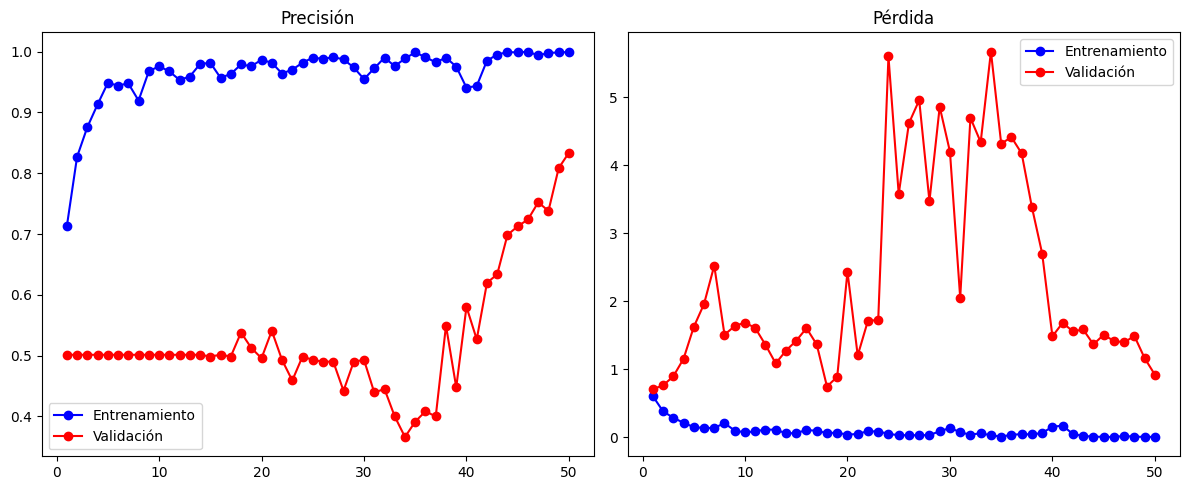

In [ ]:
acc = google_net.history['accuracy']
val_acc = google_net.history['val_accuracy']
loss = google_net.history['loss']
val_loss = google_net.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Entrenamiento')
plt.plot(epochs, val_acc, 'ro-', label='Validación')
plt.title('Precisión')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Entrenamiento')
plt.plot(epochs, val_loss, 'ro-', label='Validación')
plt.title('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

# CNN (creada desde cero)

In [ ]:
CNN_5 = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu',input_shape=(IMG_H, IMG_W, 4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(2, activation='softmax')
])

CNN_5.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
EPOCHS = 50

history_mi_modelo = CNN_5.fit(
    train_val_dataset,
    validation_data=test_val_dataset,
    epochs=EPOCHS)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 749ms/step - accuracy: 0.6045 - loss: 0.8134 - val_accuracy: 0.5014 - val_loss: 0.7756
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 200ms/step - accuracy: 0.8543 - loss: 0.4486 - val_accuracy: 0.5014 - val_loss: 0.7769
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.9146 - loss: 0.3111 - val_accuracy: 0.4986 - val_loss: 0.7768
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.9701 - loss: 0.1972 - val_accuracy: 0.4986 - val_loss: 0.7832
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step - accuracy: 0.9929 - loss: 0.1429 - val_accuracy: 0.4986 - val_loss: 0.7893
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.9961 - loss: 0.1192 - val_accuracy: 0.4986 - val_loss: 0.7984
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 330ms/step - accuracy: 0.9967 - loss: 0.1040 - val_accuracy: 0.4986 - val_loss: 0.8050
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.9840 - loss: 0.1295 - val_accuracy: 0

## Curvas de aprendizaje de la CNN

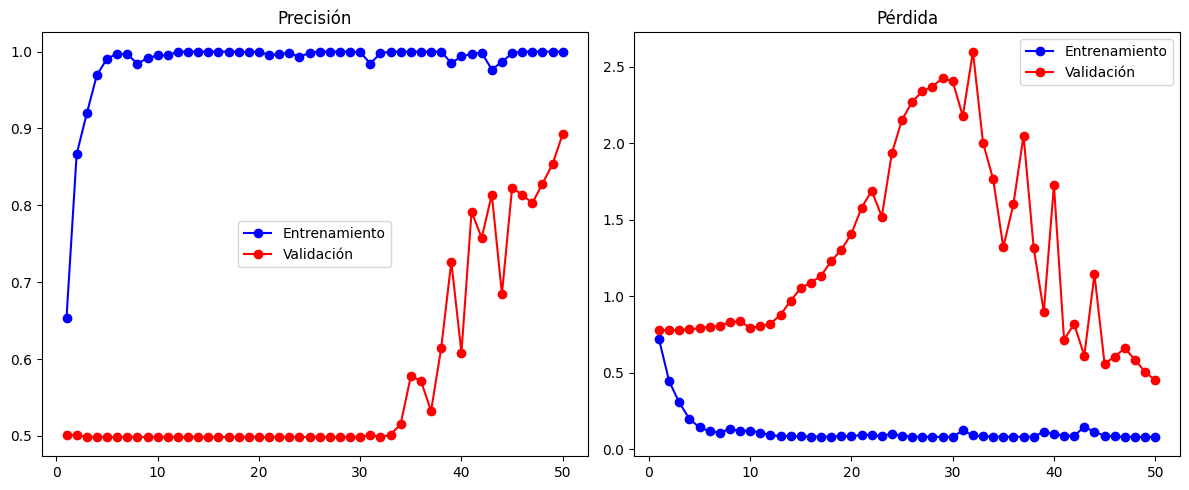

In [ ]:
acc = history_mi_modelo.history['accuracy']
val_acc = history_mi_modelo.history['val_accuracy']
loss = history_mi_modelo.history['loss']
val_loss = history_mi_modelo.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Entrenamiento')
plt.plot(epochs, val_acc, 'ro-', label='Validación')
plt.title('Precisión')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Entrenamiento')
plt.plot(epochs, val_loss, 'ro-', label='Validación')
plt.title('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

# Mejor modelo (CNN)

In [ ]:
CNN_500_final = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu',input_shape=(IMG_H, IMG_W, 4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(2, activation='softmax')
])

CNN_500_final.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
EPOCHS = 50

modelo_final = CNN_500_final.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.6280 - loss: 0.7982 - val_accuracy: 0.4966 - val_loss: 0.7751
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - accuracy: 0.8653 - loss: 0.4128 - val_accuracy: 0.4966 - val_loss: 0.7902
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - accuracy: 0.9537 - loss: 0.2400 - val_accuracy: 0.4966 - val_loss: 0.8023
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 306ms/step - accuracy: 0.9879 - loss: 0.1417 - val_accuracy: 0.4966 - val_loss: 0.8071
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.9997 - loss: 0.1024 - val_accuracy: 0.4966 - val_loss: 0.8274
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - accuracy: 0.9990 - loss: 0.0892 - val_accuracy: 0.4966 - val_loss: 0.8502
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 325ms/step - accuracy: 1.0000 - loss: 0.0842 - val_accuracy: 0.4966 - val_loss: 0.8823
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 1.0000 - loss: 0.0829 - val_accuracy: 0.4

## Curvas de aprendizaje del mejor modelo

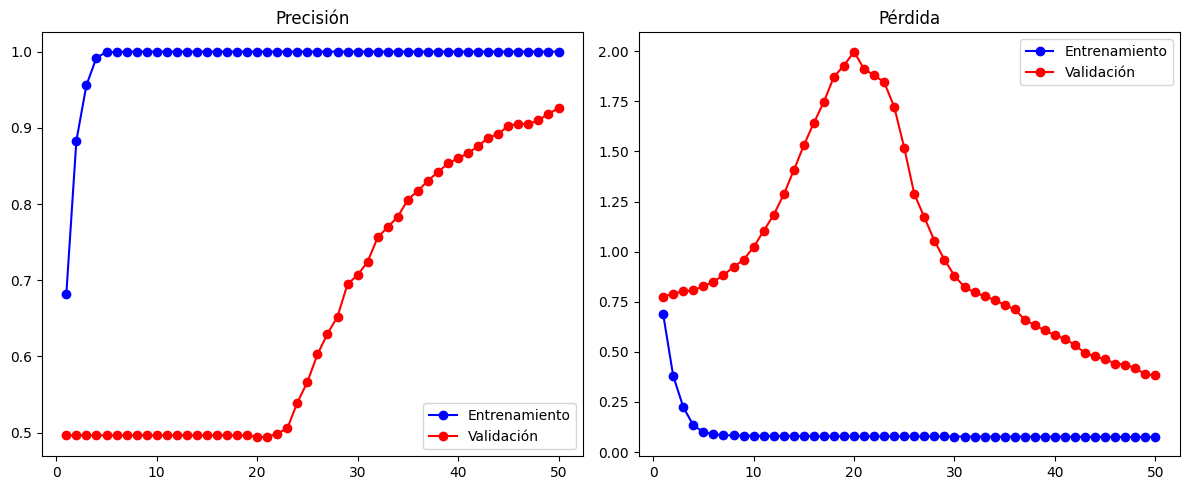

In [ ]:
acc = modelo_final.history['accuracy']
val_acc = modelo_final.history['val_accuracy']
loss = modelo_final.history['loss']
val_loss = modelo_final.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Entrenamiento')
plt.plot(epochs, val_acc, 'ro-', label='Validación')
plt.title('Precisión')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Entrenamiento')
plt.plot(epochs, val_loss, 'ro-', label='Validación')
plt.title('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

## Matriz de confusion del mejor modelo

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 527ms/step


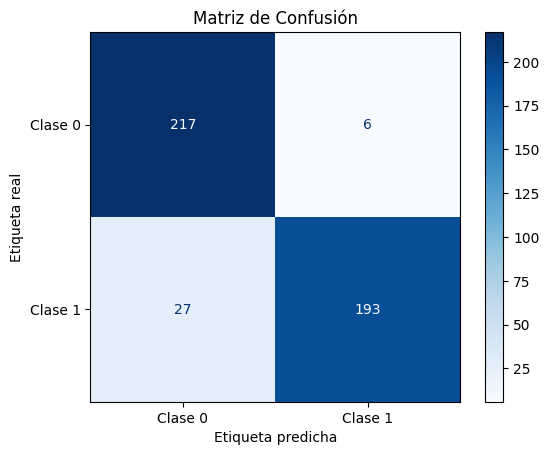

In [ ]:
y_true = np.concatenate([y.numpy() for x, y in test_dataset], axis=0)

y_proba = CNN_500_final.predict(test_dataset)
y_pred = np.argmax(y_proba, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Clase 0', 'Clase 1'])

disp.plot(cmap='Blues', colorbar=True)

plt.title("Matriz de Confusión")
plt.xlabel("Etiqueta predicha")
plt.ylabel("Etiqueta real")
plt.show()

## Reportes de las metricas del mejor modelo

In [ ]:
print("Meticas:\n",
      classification_report(y_true, y_pred, digits=4))

Meticas:
               precision    recall  f1-score   support

           0     0.8893    0.9731    0.9293       223
           1     0.9698    0.8773    0.9212       220

    accuracy                         0.9255       443
   macro avg     0.9296    0.9252    0.9253       443
weighted avg     0.9293    0.9255    0.9253       443



# Entrenamiento del mejor modelo con todo el set de datos

In [ ]:
IMG_H, IMG_W = 224, 224

def build_X_all_with_canny(X_all):

    N = X_all.shape[0]
    edges = np.zeros((N, IMG_H, IMG_W, 1), dtype=np.float32)

    for i in range(N):
        img = X_all[i]
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        e = cv2.Canny(gray, 100, 200).astype(np.float32) / 255.0
        edges[i, ..., 0] = e

    X_norm = X_all.astype(np.float32) / 255.0

    # Concatena canales RGB + Canny
    X_all_4ch = np.concatenate([X_norm, edges], axis=-1)
    return X_all_4ch

In [ ]:
X_all_4ch = build_X_all_with_canny(X_all)

In [ ]:
full_ds = (
    tf.data.Dataset
      .from_tensor_slices((X_all_4ch, y_all))
      .shuffle(1000)
      .batch(BATCH_SIZE)
      .prefetch(tf.data.AUTOTUNE)
)


In [ ]:
CNN_500_final_test = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu',input_shape=(IMG_H, IMG_W, 4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(2, activation='softmax')
])

CNN_500_final_test.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = CNN_500_final_test.fit(full_ds, epochs=50)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 650ms/step - accuracy: 0.6512 - loss: 0.8464
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.4547 - loss: 0.9063
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.5349 - loss: 0.7933
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.7847 - loss: 0.5240
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.7294 - loss: 0.6070
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.8790 - loss: 0.3820
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.9248 - loss: 0.2990
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step - accuracy: 0.9120 - loss: 0.2990
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.9480 - loss: 0.2385
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.9839 - loss: 0.1518
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - accuracy: 0.9950 - loss: 0.1073
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/ste

## Arquitectura del mejor modelo

In [ ]:
CNN_500_final_test.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 109, 109, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,243,816 (23.82 MB)

 Trainable params: 2,080,930 (7.94 MB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 4,161,862 (15.88 MB)

# Se guarda el mejor modelo

In [ ]:
CNN_500_final_test.save('/content/drive/MyDrive/CNN_final_shuffle.keras')